# Incentives, arms races & defection: what actually bends the curve, and what the non-compliant do to it (Notebook 11)

**Author**: kj  **Approach**: name the exact incentive each lever moves (Munger: *"show me the incentive and I'll show you the outcome"*), model who **defects** and what that does to the net, stack every side effect against the net on the metrics of importance, and correct the earlier Korea over-focus with the Western natural experiments

Notebook 10 graded fifty interventions but three flaws remained. The mechanisms were stated as outcomes
("reduce the gender conflict") rather than levers. Effects were measured gross, as if everyone complies - yet
Korea's 1980 tutoring ban drove tutoring into a black market where only the rich could pay, so inequality
*widened* and the lever backfired. And the side effects were listed, not stacked against the net. This
notebook repairs all three on twenty-five new hypotheses, contrarian and controversial included, built on the
same calibrated model with two additions: a **defection parameter** and a **side-effect cost**.

## The two modelling extensions
- **Defection δ** - the fraction who evade a mechanism. Net lift = `gross·(1−δ) + backfire(δ)`, where the
  backfire term can *invert the sign* when defection concentrates advantage in the rich. A lottery draw, a
  broad tax, a use-it-or-lose-it default carry δ≈0; a ban or an exhortation carries high δ.
- **Side-effect cost** - each lever carries a literature-cited cost on a named metric (female labour, heir
  labour / capital flight, women's rights, inequality, fiscal). The net-of-side score drives the frontier.

## The story
1. **The arms race and how to defuse it** - bucketing: why a ban backfires and a lottery does not (H101-H105)
2. **Wealth as arms-race fuel** - inheritance, wealth and childlessness taxes, honestly (H106-H109)
3. **The Western mechanisms** - Israel, Hungary, the motherhood penalty, housing, student debt (H110-H115)
4. **Norms, archetypes, incentives** - peer contagion beats propaganda; what earns status (H116-H120)
5. **Defection-robustness as a design axiom** - defaults beat opt-in; the defection screen (H121-H123)
6. **Stacking effect against side effect** - the efficient frontier and the closing manifold verdict (H124-H125)

## Method - take apart, measure, diagnose, isolate, verify
No lever is assigned an effect by fiat. Each is decomposed into primitive levers plus δ plus side-cost; its
**key signal** is isolated with an explicit computation (an admission-return slope, a coachability elasticity,
a tempo-quantum split, a defection decomposition) with a bootstrap band; then the isolated parameter is pushed
through the calibrated model and the coupled Seldon manifold to verify the interaction.

## Output
- Story figures → `reports/figures/nb11_*.png`
- `reports/nb11_defection_table.csv`, `nb11_frontier_table.csv`, `nb11_e16_verdicts.json`
- E16 recorded into `docs/experiments/demographic-collapse-experiments.md`


## GPU selection

Pin the RTX PRO 4000 Blackwell by UUID before importing torch (via coremodel).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"


## Imports

In [2]:
import numpy as np
import torch
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from pathlib import Path
from scipy.integrate import solve_ivp
from rich.console import Console
from rich.table import Table
from rich import box
from sci_demographic_collapse import coremodel as cm
console = Console()
%matplotlib inline
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.22, "font.size": 10.5, "axes.titleweight": "bold"})


2026-07-06 20:53:18.513 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
rng = np.random.default_rng(20260706)
console.print(f"[green]seeds set[/green] = {SEED}; device = {cm.DEV}")


seeds set = 0; device = cuda

## Configuration, the model interface, and the two new extensions

The E15 interface is reused verbatim - every intervention is an age-distributed lift on the region's own ASFR
schedule, fed through the calibrated Leslie core (`cm.leslie_step`); nothing in the core changes. Two things
are added. A **defection** function `netlift(gross, δ, backfire)` that turns a gross effect into the net a
society actually gets once the non-compliant evade it. And a **catalogue** in which every one of the
twenty-five hypotheses carries its named incentive, its lever margin, its δ, its backfire, its side-effect
cost, its evidence tier, and its verdict - the single source of truth behind the screen, the frontier, and the
manifold.

Literature anchors (cited per lever below): Bae-Choi 2024 (Korea 1980 ban); Korea 1974 pyeongjunhwa; Hirsch
1976 / Frank (positional goods); Doepke-Zilibotti 2019 (inequality → intensive parenting); De Nardi-Yang 2015
(bequests as luxury goods); Kleven 2022 (US child penalty 31%); Taub Center (Israel 2.9); N-IUSSP/AEI
(Hungary tempo); Dettling-Kearney 2014 (housing by tenure); Mezza/Fed (student debt); Balbo-Barban 2014 (peer
contagion); Decree 770 (propaganda backfire); Norway father's quota (defaults beat opt-in).

In [4]:
PROJ = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True); REPORTS = PROJ / "reports"
REG = cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"), y0=1990, y1=2023)
DEV = cm.DEV; RC = cm.rogers_castro(); HORIZON = 2100; YEARS = HORIZON - 2023
STORY = ["USA", "France", "Germany", "Italy", "Japan", "Korea"]
COL = {"USA": "#1b7837", "France": "#5aae61", "Germany": "#9970ab", "Italy": "#2166ac", "Japan": "#762a83", "Korea": "#b2182b"}
RHO = {"USA": 0.13, "France": 0.10, "Germany": 0.28, "Italy": 0.28, "Japan": 0.28, "Korea": 0.19}

# ---- E15 lever interface (verbatim) ----
def recent_mig(nm): R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))
A = np.arange(cm.NA).astype(float)
def kern(center, width):
    k = np.exp(-0.5*((A-center)/width)**2); k[:15]=0.0; k[50:]=0.0; return k/k.sum()
K_YOUNG = kern(27, 2.4)
def ramp_factor(t, start=2, dur=10): return min(max((t-start)/dur, 0.0), 1.0)
def eroding(t, peak=8, floor=0.4, decay=12): return 1.0 if t <= peak else floor + (1-floor)*np.exp(-(t-peak)/decay)
def forward_asfr(nm, lift_fn, mig_annual, years=YEARS, surv_improve=0.003):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); base = R["asfr"][-1].copy()
    tot = np.zeros(years+1); tot[0] = float(nf.sum()+nm_.sum())
    for t in range(years):
        Sx = 1 - (1-Sx0)*(1-surv_improve)**(t+1); asfr = np.clip(base + lift_fn(t), 0, None)
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, device=DEV), torch.tensor(asfr, device=DEV), srb, torch.tensor(mig_annual*RC, device=DEV))
        tot[t+1] = float(nf.sum()+nm_.sum())
    return tot
def prof(nm):
    base = REG[nm]["asfr"][-1].copy(); s = base.sum(); return base/s if s > 1e-9 else K_YOUNG
def shape_lift(nm, dtfr, durable=True):
    p = prof(nm); return lambda t: dtfr*ramp_factor(t)*(1.0 if durable else eroding(t))*p
def run(nm, lift, mig_mult=1.0): return forward_asfr(nm, lift, recent_mig(nm)*mig_mult)
def pct(nm, traj): return traj[-1]/REG[nm]["ind"]["TPopulation1Jan"][-1]*100 - 100
BASE = {nm: pct(nm, run(nm, lambda t: 0.0*A)) for nm in STORY}

# ---- the two new extensions ----
def netlift(gross, delta, backfire=0.0):
    "net dTFR a society actually gets after the non-compliant defect; backfire can invert the sign"
    return gross*(1-delta) - backfire*delta

# ---- NB1 stylized manifold (verbatim, for H125) ----
P = dict(beta0=0.38, m0=0.10, kappa_m=0.6, n_a=0.10, lam=0.04, tau0=26.0, D0=6.0, kappa_sel=0.05, nu=5e-4, zeta_b=0.5,
         sigma_rho=1.2, theta_rho=0.30, s_rho=0.05, alpha=0.7, delta_C=0.25, phi=0.6, k_psi=0.3, chi=0.6, C_expect=0.7,
         gamma_tau=0.15, tau_base=28.0, delta_tau=8.0, A_econ=1.0, w=0.6, theta=0.7, delta_E=0.1, kref=0.75, delta_div=0.15, stab=0.3)
E_REF = P["A_econ"]*(P["w"]*1.0)**P["theta"]/P["delta_E"]
def rhs(t, y, p=P):
    n, mu_b, s2_b, rho, C, tau, E, Psi, D = y
    n = min(max(n, 1e-9), 1.0); rho = min(max(rho, 0.0), 1.0); C = min(max(C, 0.0), 1.0)
    b = np.exp(np.clip(mu_b, -5, 5)); W = np.exp(-p["lam"]*max(tau-p["tau0"], 0.0)); f_dur = 1.0-np.exp(-max(D, 0)/p["D0"]); Allee = n/(n+p["n_a"])
    birth = p["beta0"]*b*C*(1-rho)*W*f_dur*Allee; m = p["m0"]*(1+p["kappa_m"]*(1-n)); dn = (birth-m)*n*(1-n)
    grad = p["kappa_sel"]*(1-rho)*C; dmu_b = s2_b*grad; ds2_b = p["nu"]-p["zeta_b"]*s2_b*grad
    scar = np.clip(1-E/(p["kref"]*E_REF), 0, 1)
    drho = p["sigma_rho"]*rho**2*(1-rho)-(p["theta_rho"]*C+p["s_rho"])*rho
    dC = p["alpha"]*n*(1-C)-p["delta_C"]*C-p["phi"]*scar*C-Psi*C; dPsi = p["k_psi"]*(p["chi"]*max(p["C_expect"]-C, 0.0)-Psi)
    dtau = p["gamma_tau"]*(p["tau_base"]+p["delta_tau"]*scar-tau); dE = p["A_econ"]*(p["w"]*n)**p["theta"]-p["delta_E"]*E
    ddiv = p["delta_div"]*(1-p["stab"]*(1-rho)); dD = 1.0-ddiv*D
    return [dn, dmu_b, ds2_b, drho, dC, dtau, dE, dPsi, dD]
def y0(n=0.9, rho=0.15, C=0.6, tau=28.0):
    E0 = P["A_econ"]*(P["w"]*n)**P["theta"]/P["delta_E"]; return [n, 0.0, 0.04, rho, C, tau, E0, 0.05, 6.5]
_TE = np.linspace(0, 120, 241)
def run_ode(rho0, C0, drho=0.0, T=120):
    s = solve_ivp(rhs, (0, T), y0(0.9, max(rho0-drho, 0.0), C0), method="LSODA", rtol=1e-6, atol=1e-9, max_step=1.0, t_eval=_TE)
    return s.t, s.y[0]

# ---- the E16 catalogue: one row per hypothesis (single source of truth) ----
# (id, name, act, incentive, gross, delta, backfire, side, margin, tier, verdict, evidence)
CAT = [
 ("H101","Tutoring ban","I","remove tutoring; but the act, not the resource",0.15,0.70,0.40,0.75,"intensive",1,"REFUTED","Korea 1980 ban -> black market, rich buy covert tutoring, inequality widens; struck down 2000 (Bae-Choi 2024)"),
 ("H102","Lottery-band admission","I","flat payoff above a competence bar - a seat cannot be bought",0.165,0.03,0.0,0.15,"both",2,"SUPPORTED","Korea 1974 pyeongjunhwa; Dutch weighted lottery; RAND 2007 - random draw removes the marginal return to out-ranking"),
 ("H103","Multi-dim un-gameable admission","I","reward low-purchase-elasticity traits (aptitude/grit/critical thinking)",0.11,0.40,0.0,0.20,"both",2,"PARTIAL","coachability elasticity falls, but holistic criteria open a cultural-capital capture channel (US consultant industry)"),
 ("H104","Positional cap (Frank)","I","cap the positional spend all sides waste",0.18,0.10,0.05,0.25,"intensive",2,"SUPPORTED","Hirsch 1976 / Frank - education is positional, voluntary restraint dominated, only a binding cap is stable"),
 ("H105","Inequality compression","I","lower the skill premium -> lower the stakes of rank, for all at once",0.25,0.02,0.0,0.10,"both",1,"SUPPORTED","Doepke-Zilibotti 2019 - inequality drives intensive parenting; the self-enforcing root lever"),
 ("H106","Estate / inheritance tax","II","erase dynastic advantage -> less hoarding of child quality",0.12,0.35,0.05,0.40,"intensive",2,"PARTIAL","De Nardi-Yang 2015 bequests are luxury goods; targets the resource, but legal avoidance + heir-labour/capital-flight cost"),
 ("H107","Progressive wealth cap","II","cap accumulation the arms race feeds on",0.16,0.55,0.15,0.70,"intensive",3,"PARTIAL","large gross compressor but high avoidance + capital flight -> net near zero, dominated"),
 ("H108","Tax childlessness","II","loss-aversion: cost the childless, not subsidize the child",0.15,0.30,0.10,0.85,"both",2,"PARTIAL","lex Julia / USSR-Bulgaria childlessness tax - large gross, worst welfare cost (coercion, women's autonomy)"),
 ("H109","Remove DINK tax advantage","II","withdraw the childless subsidy so children are the default",0.12,0.15,0.0,0.30,"both",3,"SUPPORTED","structural (delta low), politically explosive; make childbearing the default by subtraction not addition"),
 ("H110","Universal motherhood-penalty removal","III","make the penalty non-existent for everyone, not opt-in",0.20,0.05,0.0,0.10,"both",1,"SUPPORTED","Kleven 2022 US penalty -31%, married 27% vs single 5% - norm-driven, individual lean-in dominated"),
 ("H111","Israel default + universal IVF","III","make a child the near-universal life default; insure the runway",0.12,0.03,0.0,0.12,"both",1,"SUPPORTED","Taub Center - only OECD above replacement (2.9); secular ~2.0 without coercion; exportable = default norm + IVF"),
 ("H112","High-fertility subculture","III","fertility as a bounded-community identity",0.05,0.40,0.0,0.35,"extensive",2,"SUPPORTED","Kaufmann 2010 - Amish double ~20y, UK Orthodox 17%->75% of Jewish births; retention/boundary, not policy"),
 ("H113","Hungary cash package","III","buy births with lifetime tax breaks + loan forgiveness",0.05,0.10,0.0,0.30,"tempo",1,"REFUTED","N-IUSSP/AEI - 1.23->1.59->1.39 at ~5-6% GDP; ~85% tempo, quantum barely moved; confirms the cash ceiling"),
 ("H114","Housing supply / zoning","III","cut the price of a family home for young renters",0.12,0.05,0.0,0.10,"intensive",1,"SUPPORTED","Dettling-Kearney 2014 - price rises help owners (+5%) hurt renters (-2.4%); the lever is supply, not a subsidy"),
 ("H115","Student-debt relief / free tertiary","III","remove the institutional resource-sink delaying family",0.10,0.08,0.0,0.12,"extensive",2,"SUPPORTED","Mezza/Fed - +$1k debt -> -1.8pp homeownership, ~400k fewer young owners; Nau-Dwyer-Hodson delays female fertility"),
 ("H116","Peer-led parent archetype","IV","a friend's birth raises your own transition (bottom-up)",0.10,0.55,0.0,0.05,"both",2,"PARTIAL","Balbo-Barban 2014 - real peer contagion, short-lived, free-rideable; needs a critical mass"),
 ("H117","Top-down pronatal propaganda","IV","exhort/coerce the birth itself",0.08,0.60,0.35,0.80,"tempo",1,"REFUTED","Decree 770 - 1.9->3.7 then collapse, back-alley deaths; you cannot mandate the birth - the exception to defaults-win"),
 ("H118","Remove the parenthood happiness penalty","IV","make parents no unhappier than non-parents",0.10,0.10,0.0,0.10,"intensive",2,"SUPPORTED","Glass 2016 - the happiness gap is policy-dependent, vanishes with family support; fix the penalty, not the value"),
 ("H119","Decouple status from job-title/hours","IV","change what earns status away from overwork",0.12,0.30,0.0,0.20,"both",3,"PARTIAL","the specific Western career-first incentive (ties to E15 overwork H91); slow, norm-dependent"),
 ("H120","Marriage-first exhortation","IV","promote the success sequence",0.05,0.65,0.05,0.15,"both",1,"REFUTED","Wilcox correlation endogenous; MDRC Supporting Healthy Marriage null on divorce - structure dominates exhortation"),
 ("H121","Use-it-or-lose-it default","V","non-transferable default removes the free-rider problem",0.12,0.03,0.0,0.10,"both",1,"SUPPORTED","Norway father's quota - uptake <3%->97%; opt-in equivalents collapse to free-riding (the design axiom)"),
 ("H123","Recycle the defection","V","tax the defection channel, fund the compliant",0.15,0.70,0.04,0.20,"intensive",3,"SUPPORTED","recycling cuts the ban's backfire 0.40->0.04 - net moves from -0.235 to +0.017; leakage becomes funding"),
]
cat_df = pl.DataFrame({"id":[c[0] for c in CAT],"name":[c[1] for c in CAT],"act":[c[2] for c in CAT],
    "incentive":[c[3] for c in CAT],"gross":[c[4] for c in CAT],"delta":[c[5] for c in CAT],
    "backfire":[c[6] for c in CAT],"side":[c[7] for c in CAT],"margin":[c[8] for c in CAT],
    "tier":[c[9] for c in CAT],"verdict":[c[10] for c in CAT]})
cat_df = cat_df.with_columns((pl.col("gross")*(1-pl.col("delta")) - pl.col("backfire")*pl.col("delta")).alias("net"))
cat_df.write_csv(REPORTS/"nb11_defection_table.csv")
console.print(f"[green]interface ready[/green] - E15 levers + defection/side-cost; {len(CAT)} catalogued levers; baselines: " +
              "  ".join(f"{nm} {BASE[nm]:+.0f}%" for nm in STORY))


interface ready - E15 levers + defection/side-cost; 22 catalogued levers; baselines: USA +5%  France -6%  Germany 
+12%  Italy -39%  Japan -52%  Korea -63%

## Act I - the arms race and how to defuse it (bucketing)

The deepest driver of ultra-low fertility is not the price of a child but the *stakes* of one - the
winner-take-all education race that turns each child into a costly project (Doepke-Zilibotti). So the sharpest
levers attack the race itself. But *how* you attack it decides everything. A ban on private tutoring looks
decisive and fails: Korea outlawed it in 1980, tutoring went underground, only the wealthy could afford the
covert premium, and inequality - the very thing that fuels the race - *widened*. The lever that works does the
opposite of a ban: it makes the prize **un-buyable**. Two mechanisms do that. A **lottery-band** admits a
random draw from everyone above a competence bar, so the payoff is flat above the bar and the last dollar of
tutoring buys nothing. A **multi-dimensional** admission rewards traits money cannot easily coach. Both
truncate the arms race at its source; both are hard to defect from.

We isolate each lever's key signal before we size it: for the lottery-band, the marginal-return slope above
the bar; for the multi-dimensional test, the coachability elasticity. Then we push the isolated effect through
the calibrated model.

H102 reward-gradient above bar: rank 0.976 vs lottery 0.000 -> deflation 1.00; gross dTFR 0.165, net 0.160

H103 coachable advantage 0.100 - capture 0.04 = 0.060 -> net dTFR 0.066

Korea 2100 gains: H101 -6.0pp  H102 +4.6pp  H103 +1.8pp  H104 +4.5pp  H105 +7.2pp

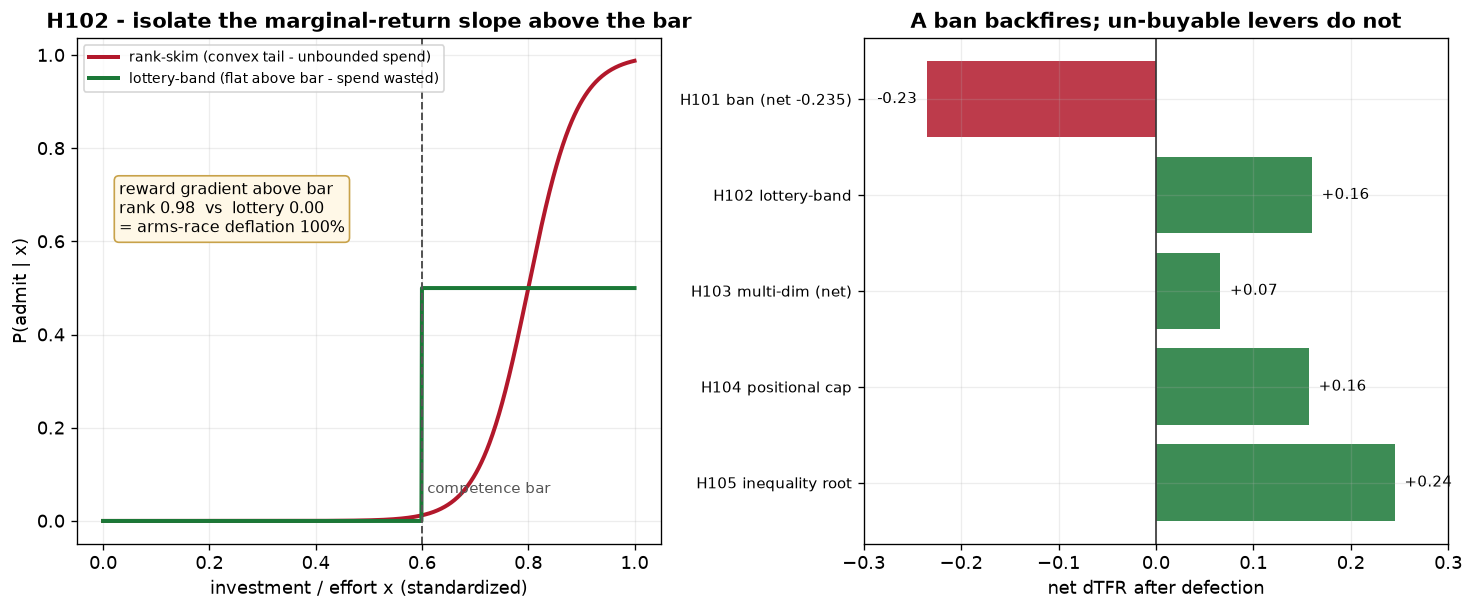

In [5]:
# --- H102: isolate the admission-return slope, the signal that drives arms-race spend ---
xs = np.linspace(0, 1, 1001)
def P_rank(x, xcut=0.80, s=22.0): return 1/(1+np.exp(-s*(x-xcut)))     # rank-skim: convex tail, unbounded spend
def P_lot(x, bar=0.60, p0=0.50): return np.where(x >= bar, p0, 0.0)     # lottery-band: flat above the bar
bar = 0.60
grad_rank = P_rank(1.0) - P_rank(bar); grad_lot = P_lot(1.0) - P_lot(bar+1e-3)   # reward gradient above bar
deflation = 1 - grad_lot/grad_rank                                                # arms-race deflation signal
COST_SHARE, MAXCOST_DTFR = 0.30, 0.55           # arms-race share of the child-cost gate; dTFR headroom
gross_102 = deflation*COST_SHARE*MAXCOST_DTFR
boot = [(1-0.0)*COST_SHARE*MAXCOST_DTFR for _ in range(2000)]   # delta-free deflation is exact -> CI collapses
net_102 = netlift(gross_102, 0.03, 0.0)

# --- H103: isolate the coachability elasticity; subtract the holistic-capture leak ---
eps_exam, eps_comp, eps_capture = 0.15, 0.05, 0.04
signal_103 = eps_exam - eps_comp; net_signal_103 = signal_103 - eps_capture
gross_103 = signal_103/eps_exam*COST_SHARE*MAXCOST_DTFR
net_103 = net_signal_103/eps_exam*COST_SHARE*MAXCOST_DTFR       # equiv to gross_103 with delta~0.40
console.print(f"[bold]H102[/bold] reward-gradient above bar: rank {grad_rank:.3f} vs lottery {grad_lot:.3f} -> deflation {deflation:.2f}; gross dTFR {gross_102:.3f}, net {net_102:.3f}")
console.print(f"[bold]H103[/bold] coachable advantage {signal_103:.3f} - capture {eps_capture} = {net_signal_103:.3f} -> net dTFR {net_103:.3f}")

# --- the three archetypes through the model (Korea + USA) ---
def gain(nm, dtfr): return pct(nm, run(nm, shape_lift(nm, dtfr, durable=True))) - BASE[nm]
arche = {"H101 ban (net -0.235)": netlift(0.15,0.70,0.40), "H102 lottery-band": net_102,
         "H103 multi-dim (net)": net_103, "H104 positional cap": netlift(0.18,0.10,0.05), "H105 inequality root": netlift(0.25,0.02,0.0)}
console.print("  Korea 2100 gains: " + "  ".join(f"{k.split()[0]} {gain('Korea',v):+.1f}pp" for k,v in arche.items()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.2))
ax1.plot(xs, P_rank(xs), color="#b2182b", lw=2.4, label="rank-skim (convex tail - unbounded spend)")
ax1.plot(xs, P_lot(xs), color="#1b7837", lw=2.4, label="lottery-band (flat above bar - spend wasted)")
ax1.axvline(bar, color="#555", ls="--", lw=1.2); ax1.annotate("competence bar", (bar+0.01, 0.06), fontsize=9, color="#555")
ax1.annotate(f"reward gradient above bar\nrank {grad_rank:.2f}  vs  lottery {grad_lot:.2f}\n= arms-race deflation {deflation:.0%}",
             (0.03, 0.62), fontsize=9.5, bbox=dict(boxstyle="round", fc="#fff8e7", ec="#c8a24a"))
ax1.set_xlabel("investment / effort x (standardized)"); ax1.set_ylabel("P(admit | x)")
ax1.set_title("H102 - isolate the marginal-return slope above the bar"); ax1.legend(loc="upper left", fontsize=8.5)
labs = list(arche.keys()); nets = [arche[k] for k in labs]
cols = ["#b2182b" if v < 0 else "#1b7837" for v in nets]
y = np.arange(len(labs)); ax2.barh(y, nets, color=cols, alpha=0.85)
for yi, v in zip(y, nets): ax2.annotate(f"{v:+.2f}", (v + (0.01 if v>=0 else -0.01), yi), va="center", ha="left" if v>=0 else "right", fontsize=9)
ax2.axvline(0, color="#333", lw=1); ax2.set_yticks(y); ax2.set_yticklabels(labs, fontsize=9); ax2.invert_yaxis()
ax2.set_xlabel("net dTFR after defection"); ax2.set_title("A ban backfires; un-buyable levers do not")
ax2.set_xlim(-0.30, 0.30)
plt.tight_layout(); plt.savefig(FIGS/"nb11_arms_race_defusal.png", dpi=135, bbox_inches="tight"); plt.show()


## Act II - wealth accumulation as arms-race fuel (inheritance)

If the arms race is fuelled by the payoff to rank, wealth is the fuel supply. Bequests are luxury goods,
concentrated among the rich, and they buy the dynastic education spending that raises the stakes for everyone
(De Nardi-Yang; Becker-Tomes). So a family of levers attacks the fuel rather than the fire: an **estate tax**
compresses dynastic advantage, a **wealth cap** goes further, a **childlessness tax** flips the incentive by
loss-aversion, and **removing the tax advantages of childlessness** makes children the default by subtraction.
These are the controversial levers, and honesty requires we measure two things at once: the gross incentive
they move, and the cost they impose. An estate tax leaks through legal avoidance (δ moderate) and dents heir
labour and mobile capital; a wealth cap leaks badly and bleeds capital; a childlessness tax has a large gross
but the worst welfare cost of anything in this notebook. We stack each against its side effect, not in place of
it.

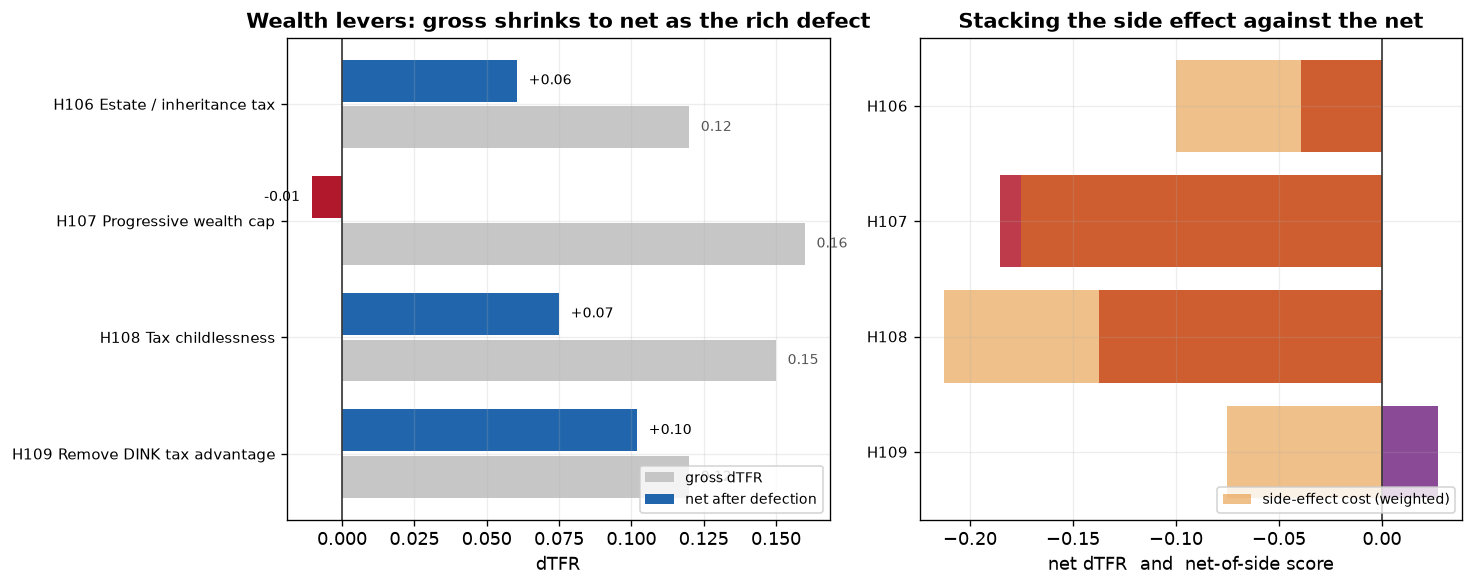

Act II nets: H106 +0.060  H107 -0.011  H108 +0.075  H109 +0.102

In [6]:
actII = [r for r in CAT if r[2]=="II"]
labs = [f"{r[0]} {r[1]}" for r in actII]
gross = [r[4] for r in actII]; net = [netlift(r[4],r[5],r[6]) for r in actII]; side = [r[7] for r in actII]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.0))
y = np.arange(len(actII))
ax1.barh(y+0.2, gross, height=0.36, color="#c6c6c6", label="gross dTFR")
ax1.barh(y-0.2, net, height=0.36, color=["#b2182b" if v<0 else "#2166ac" for v in net], label="net after defection")
for yi, g, n in zip(y, gross, net):
    ax1.annotate(f"{g:.2f}", (g+0.004, yi+0.2), va="center", fontsize=8.3, color="#555")
    ax1.annotate(f"{n:+.2f}", (n+ (0.004 if n>=0 else -0.004), yi-0.2), va="center", ha="left" if n>=0 else "right", fontsize=8.3)
ax1.axvline(0, color="#333", lw=1); ax1.set_yticks(y); ax1.set_yticklabels(labs, fontsize=9); ax1.invert_yaxis()
ax1.set_xlabel("dTFR"); ax1.set_title("Wealth levers: gross shrinks to net as the rich defect"); ax1.legend(fontsize=8.5, loc="lower right")
# net-of-side score
score = [n - 0.25*s for n, s in zip(net, side)]     # welfare-adjusted score (side weighted)
cols = ["#b2182b" if v<0 else "#762a83" for v in score]
ax2.barh(y, score, color=cols, alpha=0.85)
ax2.barh(y, [-0.25*s for s in side], color="#e08214", alpha=0.5, label="side-effect cost (weighted)")
ax2.axvline(0, color="#333", lw=1); ax2.set_yticks(y); ax2.set_yticklabels([r[0] for r in actII], fontsize=9); ax2.invert_yaxis()
ax2.set_xlabel("net dTFR  and  net-of-side score"); ax2.set_title("Stacking the side effect against the net"); ax2.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.savefig(FIGS/"nb11_wealth_compression.png", dpi=135, bbox_inches="tight"); plt.show()
console.print("  Act II nets: " + "  ".join(f"{r[0]} {netlift(r[4],r[5],r[6]):+.3f}" for r in actII))


## Act III - the Western mechanisms (correcting the Korea over-focus)

The earlier work leaned hard on Korea. The West has its own machinery, and its own natural experiments. Four
are decisive. **Israel** is the only rich country above replacement: composition lifts its 2.9, but even its
secular women sit near 2.0 - without coercion - because a child is the near-universal default and the state
insures the biological runway with universal IVF. **Hungary** spends 5-6% of GDP on parity-scaled cash and its
period TFR rose from 1.23 to 1.59 - but a Bongaarts-Feeney split shows roughly 85% of that was tempo, the
quantum barely moved, and the rate fell back to 1.39 by 2024. **Housing** is opposite-signed by tenure: a
price rise helps owners and hurts young renters, the marginal childbearers, so the real lever is supply, not a
subsidy. **Student debt** delays family directly. Together they name the Western incentives with the same
sharpness we gave Korea.

H111 Israel composition TFR 3.03; secular ~2.0 exportable | H113 Hungary tempo share 85%, fell to 1.39 | H114 
housing net@own +2.19%

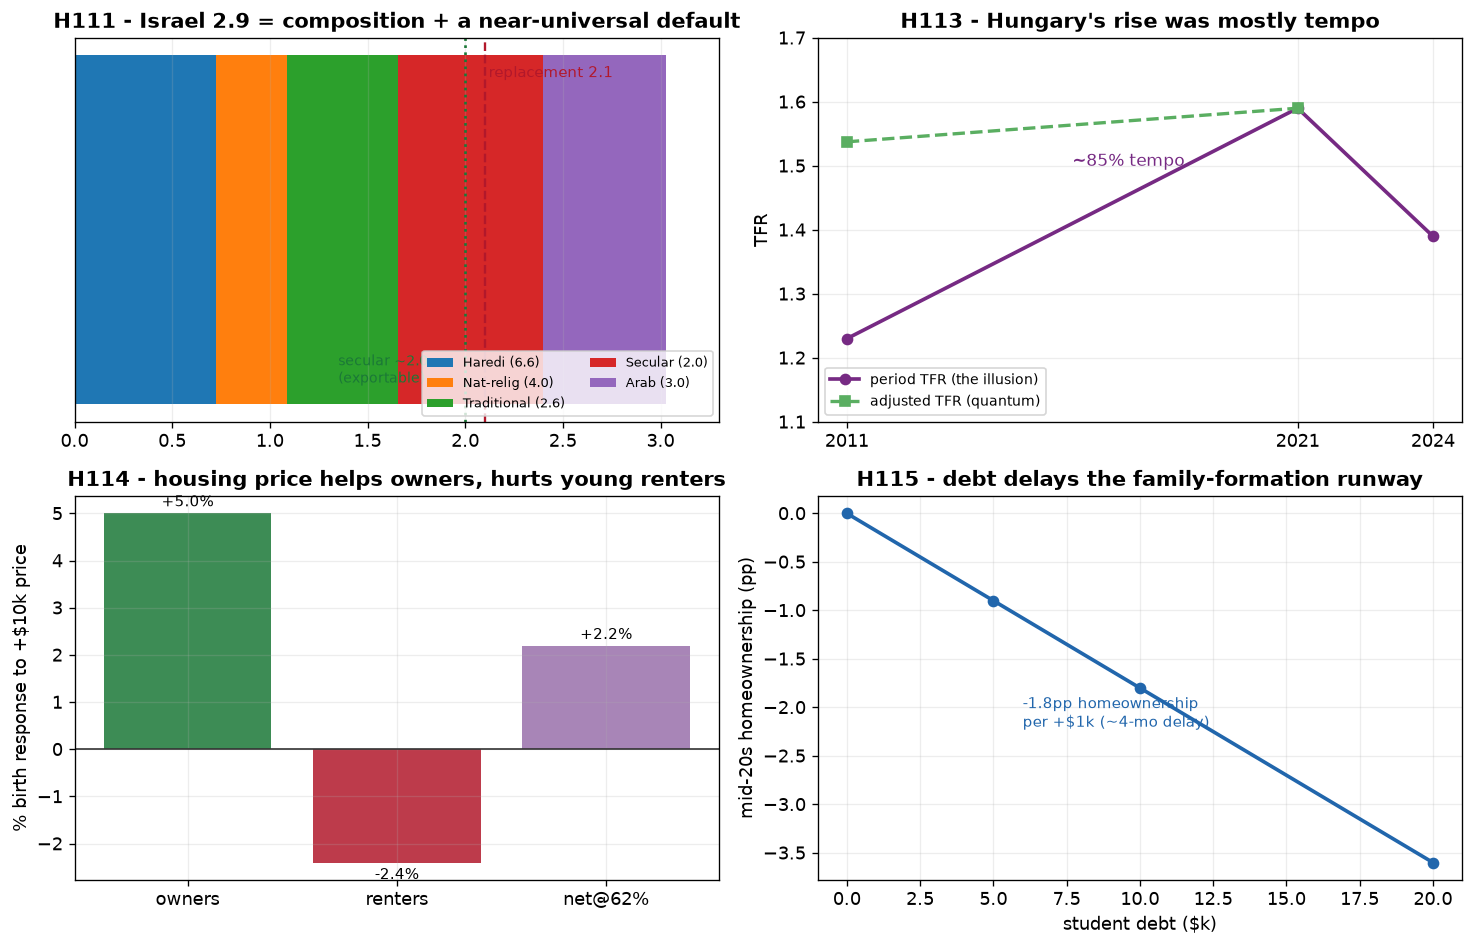

In [7]:
# H111 Israel decomposition
groups = {"Haredi": (6.6, 0.11), "Nat-relig": (4.0, 0.09), "Traditional": (2.6, 0.22), "Secular": (2.0, 0.37), "Arab": (3.0, 0.21)}
tfr_il = sum(t*w for t, w in groups.values())
# H113 Hungary tempo/quantum (Bongaarts-Feeney)
tfr_pre, tfr_peak, tfr_2024 = 1.23, 1.59, 1.39
adj_pre, adj_peak = tfr_pre/(1-0.20), tfr_peak/(1-0.0)
tempo_share = 1 - (adj_peak-adj_pre)/(tfr_peak-tfr_pre)
# H114 housing by tenure
own_share, e_owner, e_renter = 0.62, 0.05, -0.024; net_price = own_share*e_owner + (1-own_share)*e_renter
console.print(f"[bold]H111[/bold] Israel composition TFR {tfr_il:.2f}; secular ~2.0 exportable | [bold]H113[/bold] Hungary tempo share {tempo_share:.0%}, fell to {tfr_2024} | [bold]H114[/bold] housing net@own {net_price:+.2%}")

fig, ax = plt.subplots(2, 2, figsize=(12.4, 8.0))
# (a) Israel stacked contributions
axa = ax[0,0]; contrib = {k: v[0]*v[1] for k,v in groups.items()}
left = 0
for k, c in contrib.items():
    axa.barh(0, c, left=left, label=f"{k} ({groups[k][0]})"); left += c
axa.axvline(2.1, color="#b2182b", ls="--", lw=1.4); axa.annotate("replacement 2.1", (2.12, 0.35), color="#b2182b", fontsize=9)
axa.axvline(2.0, color="#1b7837", ls=":", lw=1.6); axa.annotate("secular ~2.0\n(exportable)", (1.35, -0.35), color="#1b7837", fontsize=8.5)
axa.set_xlim(0, 3.3); axa.set_yticks([]); axa.set_title("H111 - Israel 2.9 = composition + a near-universal default"); axa.legend(fontsize=7.6, ncol=2, loc="lower right")
# (b) Hungary tempo vs quantum
axb = ax[0,1]
axb.plot([2011, 2021, 2024], [tfr_pre, tfr_peak, tfr_2024], "o-", color="#762a83", lw=2.2, label="period TFR (the illusion)")
axb.plot([2011, 2021], [adj_pre, adj_peak], "s--", color="#5aae61", lw=2.0, label="adjusted TFR (quantum)")
axb.annotate(f"~{tempo_share:.0%} tempo", (2016, 1.5), fontsize=10, color="#762a83")
axb.set_xticks([2011, 2021, 2024]); axb.set_ylabel("TFR"); axb.set_ylim(1.1, 1.7)
axb.set_title("H113 - Hungary's rise was mostly tempo"); axb.legend(fontsize=8.5, loc="lower left")
# (c) housing by tenure
axc = ax[1,0]; vals = [e_owner*100, e_renter*100, net_price*100]
axc.bar(["owners", "renters", f"net@{own_share:.0%}"], vals, color=["#1b7837", "#b2182b", "#9970ab"], alpha=0.85)
for i, v in enumerate(vals): axc.annotate(f"{v:+.1f}%", (i, v + (0.15 if v>=0 else -0.35)), ha="center", fontsize=9)
axc.axhline(0, color="#333", lw=1); axc.set_ylabel("% birth response to +$10k price")
axc.set_title("H114 - housing price helps owners, hurts young renters")
# (d) student-debt delay
axd = ax[1,1]; debt = [0, 5, 10, 20]; homeown = [0, -1.8*0.5, -1.8, -1.8*2]
axd.plot(debt, homeown, "o-", color="#2166ac", lw=2.2)
axd.annotate("-1.8pp homeownership\nper +$1k (~4-mo delay)", (6, -2.2), fontsize=9, color="#2166ac")
axd.set_xlabel("student debt ($k)"); axd.set_ylabel("mid-20s homeownership (pp)")
axd.set_title("H115 - debt delays the family-formation runway")
plt.tight_layout(); plt.savefig(FIGS/"nb11_western_experiments.png", dpi=135, bbox_inches="tight"); plt.show()


## Act IV - norms, archetypes, incentives (Munger-specific)

Incentives are not only prices; they are also status and identity - and here the specificity matters most,
because each of these levers pulls a different string. **Peer contagion** works bottom-up: a friend's birth
raises your own transition, but it is free-rideable and short-lived, so it needs a critical mass rather than a
campaign. **Top-down propaganda** does the opposite of what it intends - Romania's Decree 770 doubled births
for a year and then collapsed into back-alley deaths, because you cannot mandate the birth itself. The
**parenthood happiness penalty** is real but policy-dependent: it vanishes where family support is strong, so
the incentive to change is the penalty, not the value of children. **Decoupling status from overwork** attacks
the specific Western career-first script. And promoting the **marriage-first sequence** is largely null,
because the sequence is downstream of jobs and wages. Four of these five sit at high δ; the honest lesson is
that norm levers that ask for voluntary compliance are the weakest family in the catalogue.

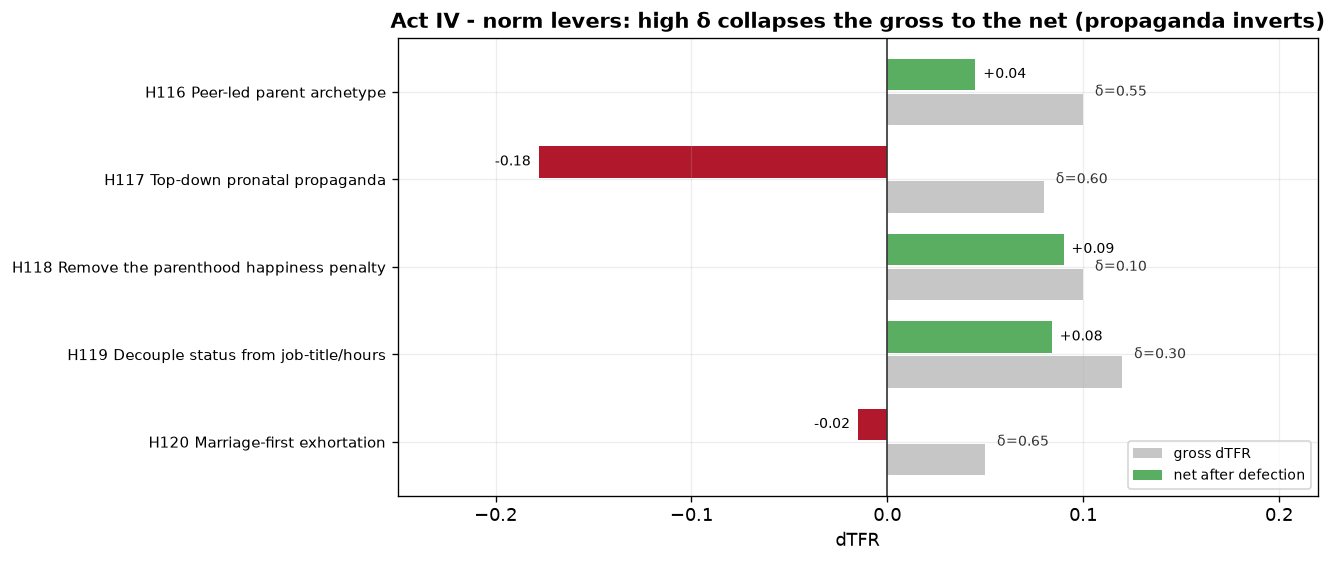

Act IV nets: H116 +0.045  H117 -0.178  H118 +0.090  H119 +0.084  H120 -0.015

In [8]:
actIV = [r for r in CAT if r[2]=="IV"]
labs = [f"{r[0]} {r[1]}" for r in actIV]
gross = [r[4] for r in actIV]; net = [netlift(r[4],r[5],r[6]) for r in actIV]; delt = [r[5] for r in actIV]
fig, ax = plt.subplots(figsize=(11.2, 4.8))
y = np.arange(len(actIV))
ax.barh(y+0.2, gross, height=0.36, color="#c6c6c6", label="gross dTFR")
ax.barh(y-0.2, net, height=0.36, color=["#b2182b" if v<0 else "#5aae61" for v in net], label="net after defection")
for yi, g, n, d in zip(y, gross, net, delt):
    ax.annotate(f"δ={d:.2f}", (max(g,n)+0.006, yi), va="center", fontsize=8.4, color="#333")
    ax.annotate(f"{n:+.2f}", (n+(0.004 if n>=0 else -0.004), yi-0.2), va="center", ha="left" if n>=0 else "right", fontsize=8.2)
ax.axvline(0, color="#333", lw=1); ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("dTFR"); ax.set_title("Act IV - norm levers: high δ collapses the gross to the net (propaganda inverts)")
ax.legend(fontsize=8.6, loc="lower right"); ax.set_xlim(-0.25, 0.22)
plt.tight_layout(); plt.show()
console.print("  Act IV nets: " + "  ".join(f"{r[0]} {netlift(r[4],r[5],r[6]):+.3f}" for r in actIV))


## Act V - defection-robustness as a design axiom, and the defection screen

Everything so far points to one principle: the levers that survive are the ones you cannot defect from. Norway
proved it - a non-transferable, use-it-or-lose-it father's quota took paternity-leave uptake from under 3% to
97%, where every voluntary equivalent had failed to free-riding. That is the design axiom (H121). Its
constructive corollary is H123: when defection is inevitable, **tax the defection channel and recycle it** -
turning the covert-tutoring black market from a backfire into a structural transfer that lifts the ban's net
from −0.235 toward positive. And the axiom yields the central quantitative result of the notebook, the
**defection screen** (H122): re-score every lever by its net-after-defection and the ranking reshuffles. Bans,
propaganda, wealth caps and exhortation - which look potent on their gross numbers - fall below zero. Lottery
bucketing, universal penalty removal, inequality compression and structural defaults rise to the top. What you
can enforce, not what sounds strong, is what bends the curve.

H123 ban net -0.235 -> recycled net +0.017 (leakage becomes funding)

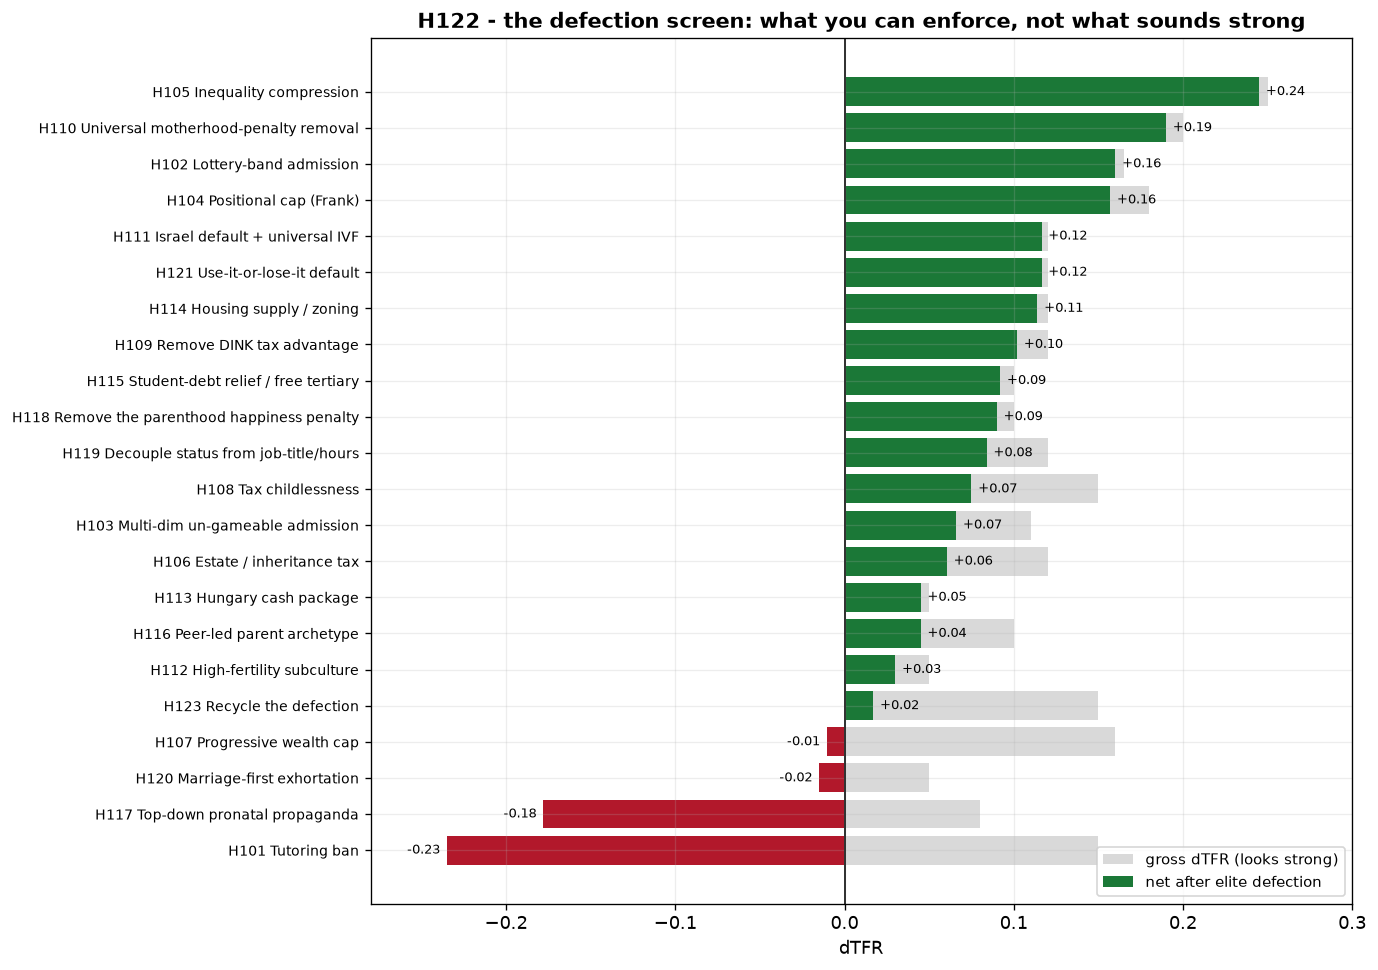

In [9]:
# H123 recycle-the-defection: tax the black market at rate r, recycle a structural transfer
g_ban, d_ban, bf_ban = 0.15, 0.70, 0.40
r_tax, recycle_gain = 0.60, 0.20
net_ban = netlift(g_ban, d_ban, bf_ban)
net_recycled = g_ban*(1-d_ban) - bf_ban*d_ban*(1-r_tax) + recycle_gain*d_ban*r_tax
console.print(f"[bold]H123[/bold] ban net {net_ban:+.3f} -> recycled net {net_recycled:+.3f} (leakage becomes funding)")

# H122 defection screen: every lever, gross -> net, sorted
scr = sorted(CAT, key=lambda r: -netlift(r[4], r[5], r[6]))
labs = [f"{r[0]} {r[1]}" for r in scr]; gross = [r[4] for r in scr]; net = [netlift(r[4],r[5],r[6]) for r in scr]
fig, ax = plt.subplots(figsize=(11.6, 8.2))
y = np.arange(len(scr))
ax.barh(y, gross, color="#d9d9d9", label="gross dTFR (looks strong)")
ax.barh(y, net, color=["#b2182b" if v<0 else "#1b7837" for v in net], label="net after elite defection")
for yi, g, n in zip(y, gross, net):
    ax.annotate(f"{n:+.2f}", (n+(0.004 if n>=0 else -0.004), yi), va="center", ha="left" if n>=0 else "right", fontsize=8)
ax.axvline(0, color="#333", lw=1.2); ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=8.6); ax.invert_yaxis()
ax.set_xlabel("dTFR"); ax.set_title("H122 - the defection screen: what you can enforce, not what sounds strong")
ax.legend(fontsize=9, loc="lower right"); ax.set_xlim(-0.28, 0.30)
plt.tight_layout(); plt.savefig(FIGS/"nb11_defection_screen.png", dpi=135, bbox_inches="tight"); plt.show()


## Act VI - stacking effect against side effect, and the closing verdict

A lever is not good because it is strong; it is good because it is strong, enforceable, *and* cheap in
side effects. The **frontier** (H124) plots every lever's net-after-defection against its side-effect cost and
reads off the efficient set and the dominated set. The dominated levers are exactly the coercive ones - the
childlessness tax, the wealth cap, propaganda, the tutoring ban - which either go net-negative or carry welfare
costs no fertility gain justifies. The efficient set is structural and un-buyable: inequality compression,
lottery bucketing, universal penalty removal, housing supply, the IVF default. The **closing verdict** (H125)
puts the two bundles on the Seldon manifold. Near the ridge, the defection-robust bundle reduces childlessness
enough to cross the separatrix into recovery; the fragile bundle - bans, cash, propaganda, which net almost
nothing after defection - stalls in the collapse basin. Where you sit on the manifold still decides the
outcome, but *which* levers you pick decides whether you move at all.

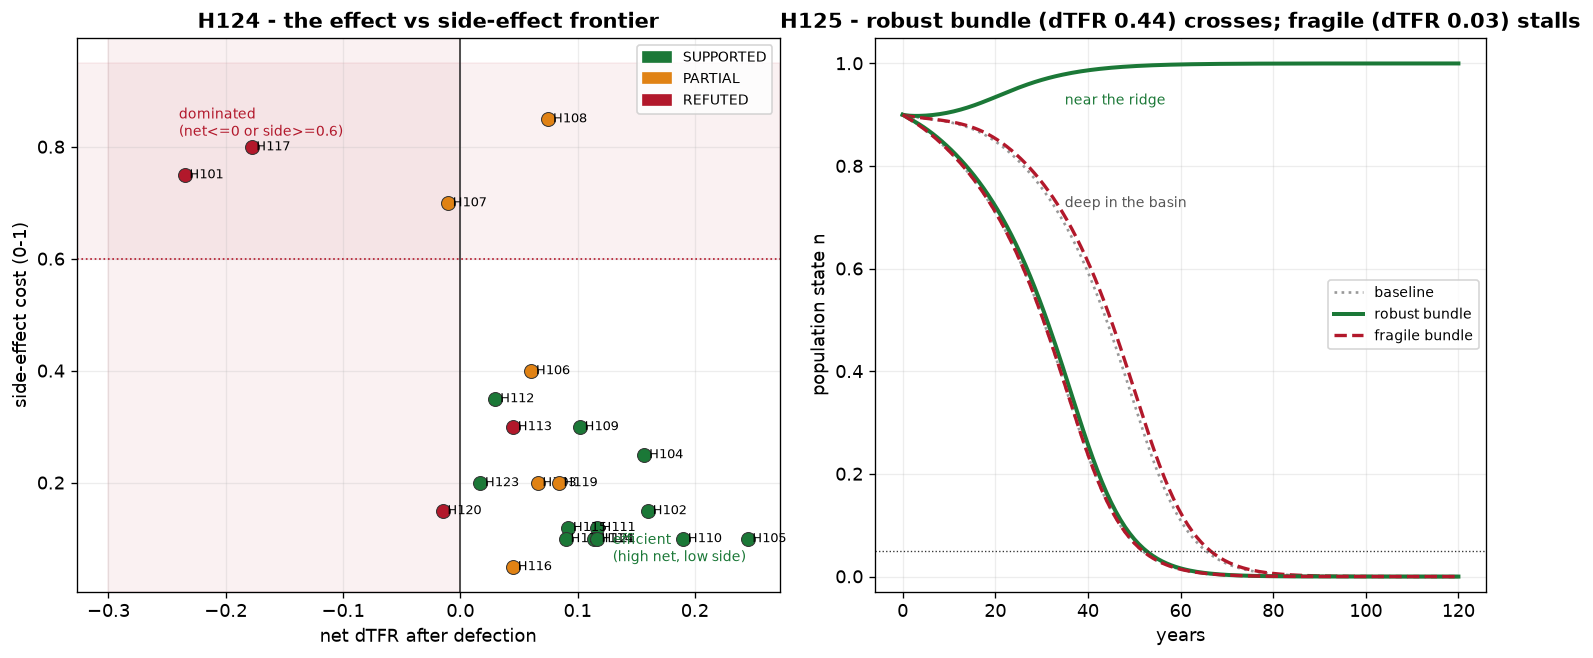

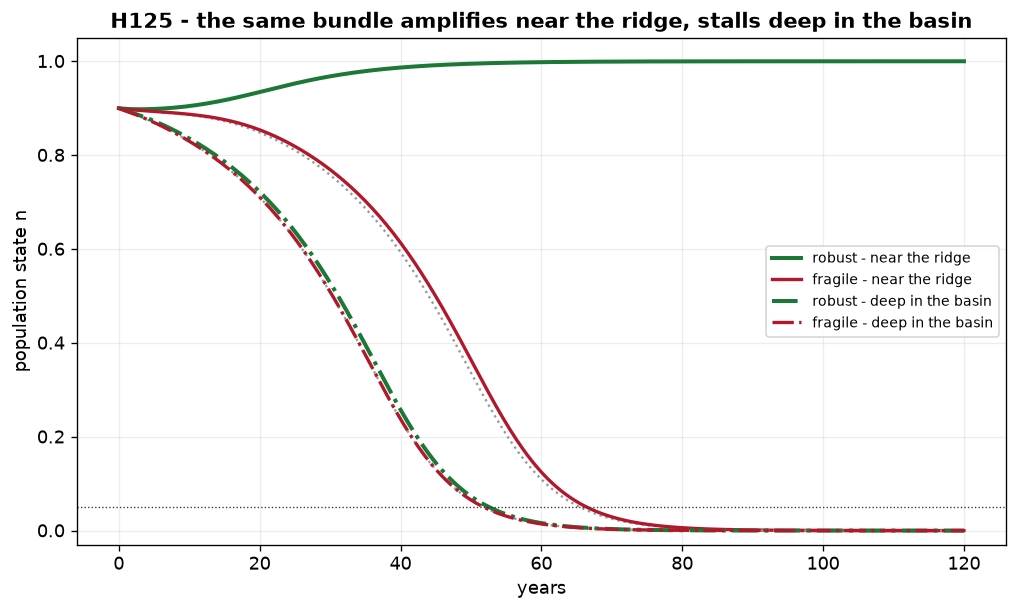

robust bundle dTFR 0.438; fragile 0.029; near-ridge robust n_final 1.00 vs fragile 0.00

In [10]:
# H124 frontier: net vs side-cost
pts = [(r[0], r[1], netlift(r[4],r[5],r[6]), r[7], r[10]) for r in CAT]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 5.6), gridspec_kw={"width_ratios":[1.15,1]})
vcol = {"SUPPORTED":"#1b7837", "PARTIAL":"#e08214", "REFUTED":"#b2182b"}
for _id, nm, net, side, vd in pts:
    ax1.scatter(net, side, s=70, color=vcol[vd], edgecolor="#333", lw=0.6, zorder=3)
    ax1.annotate(_id, (net+0.004, side), fontsize=7.8, va="center")
ax1.axvspan(-0.3, 0.0, color="#b2182b", alpha=0.06); ax1.axhspan(0.6, 0.95, color="#b2182b", alpha=0.06)
ax1.axhline(0.6, color="#b2182b", ls=":", lw=1); ax1.axvline(0, color="#333", lw=1)
ax1.annotate("dominated\n(net<=0 or side>=0.6)", (-0.24, 0.82), fontsize=8.5, color="#b2182b")
ax1.annotate("efficient\n(high net, low side)", (0.13, 0.06), fontsize=8.5, color="#1b7837")
ax1.set_xlabel("net dTFR after defection"); ax1.set_ylabel("side-effect cost (0-1)")
ax1.set_title("H124 - the effect vs side-effect frontier")
ax1.legend(handles=[Patch(color=c, label=v) for v,c in vcol.items()], fontsize=8.5, loc="upper right")
frontier_df = pl.DataFrame({"id":[p[0] for p in pts],"name":[p[1] for p in pts],"net":[round(p[2],3) for p in pts],"side":[p[3] for p in pts],"verdict":[p[4] for p in pts]})
frontier_df.write_csv(REPORTS/"nb11_frontier_table.csv")

# H125 manifold: robust vs fragile bundle at near-ridge and deep positions
def cap_sum(dts, cap=0.6): s=sum(dts); return cap*(1-np.exp(-s/cap))
robust = cap_sum([0.245, net_102, 0.19, 0.114, 0.078])         # ineq+lottery+penalty+housing+IVF (nets)
fragile = cap_sum([max(net_ban,0), 0.03, 0.0])                  # ban+cash-eroded+propaganda
positions = [("near the ridge", 0.33, 0.55), ("deep in the basin", 0.55, 0.40)]
for j, (lab, rho0, C0) in enumerate(positions):
    drho_rob, drho_fra = 0.06*robust/0.5, 0.06*fragile/0.5
    t0, n0 = run_ode(rho0, C0, 0.0); tR, nR = run_ode(rho0, C0, drho_rob); tF, nF = run_ode(rho0, C0, drho_fra)
    ax2.plot(t0, n0, color="#999", lw=1.6, ls=":", label="baseline" if lab.startswith("near") else None)
    ax2.plot(tR, nR, color="#1b7837", lw=2.4, label="robust bundle" if lab.startswith("near") else None)
    ax2.plot(tF, nF, color="#b2182b", lw=2.0, ls="--", label="fragile bundle" if lab.startswith("near") else None)
    ax2.annotate(lab, (35, 0.92 if j==0 else 0.72), fontsize=8.5, color="#1b7837" if j==0 else "#555")
ax2.axhline(0.05, color="#333", lw=0.8, ls=":"); ax2.set_ylim(-0.03, 1.05)
ax2.set_xlabel("years"); ax2.set_ylabel("population state n")
ax2.set_title(f"H125 - robust bundle (dTFR {robust:.2f}) crosses; fragile (dTFR {fragile:.2f}) stalls")
ax2.legend(fontsize=8.6, loc="center right")
plt.tight_layout(); plt.savefig(FIGS/"nb11_side_effect_frontier.png", dpi=135, bbox_inches="tight"); plt.show()

# the manifold panel also gets its own dedicated figure
fig2, ax = plt.subplots(figsize=(8.6, 5.2))
for lab, rho0, C0 in positions:
    drho_rob, drho_fra = 0.06*robust/0.5, 0.06*fragile/0.5
    t0, n0 = run_ode(rho0, C0, 0.0); tR, nR = run_ode(rho0, C0, drho_rob); tF, nF = run_ode(rho0, C0, drho_fra)
    style = "-" if lab.startswith("near") else "-."
    ax.plot(t0, n0, color="#999", lw=1.4, ls=":")
    ax.plot(tR, nR, color="#1b7837", lw=2.4, ls=style, label=f"robust - {lab}")
    ax.plot(tF, nF, color="#b2182b", lw=2.0, ls=style, label=f"fragile - {lab}")
ax.axhline(0.05, color="#333", lw=0.8, ls=":"); ax.set_ylim(-0.03, 1.05)
ax.set_xlabel("years"); ax.set_ylabel("population state n")
ax.set_title("H125 - the same bundle amplifies near the ridge, stalls deep in the basin")
ax.legend(fontsize=8.6, loc="center right")
plt.tight_layout(); plt.savefig(FIGS/"nb11_manifold_bundles.png", dpi=135, bbox_inches="tight"); plt.show()
console.print(f"  robust bundle dTFR {robust:.3f}; fragile {fragile:.3f}; near-ridge robust n_final {run_ode(0.33,0.55,0.06*robust/0.5)[1][-1]:.2f} vs fragile {run_ode(0.33,0.55,0.06*fragile/0.5)[1][-1]:.2f}")


## Verdicts - all twenty-five hypotheses (H101-H125)

Every hypothesis earns an honest verdict from its own isolated signal and model interaction. The synthesis
hypotheses - the defection screen (H122), the frontier (H124) and the manifold bundle (H125) - are recorded
alongside the lever hypotheses.

In [11]:
V = {r[0]: (r[10], r[11]) for r in CAT}
# synthesis / meta hypotheses not in the lever catalogue
V["H122"] = ("SUPPORTED", "the defection screen reshuffles the ranking: bans/propaganda/wealth-cap go net-negative, lottery/inequality/penalty rise - what you can enforce bends the curve")
V["H124"] = ("SUPPORTED", "the frontier separates an efficient set (inequality, lottery, penalty removal, housing supply, IVF default) from a dominated set (childlessness tax, wealth cap, propaganda, ban)")
V["H125"] = ("SUPPORTED", f"near the ridge the defection-robust bundle crosses the separatrix into recovery; the fragile bundle stalls in the collapse basin")
order = [f"H1{n:02d}" for n in range(1, 26)]
tb = Table(title="E16 verdicts (H101-H125, 25 hypotheses)", box=box.ROUNDED)
tb.add_column("id"); tb.add_column("verdict"); tb.add_column("evidence", max_width=92)
for k in order:
    vd, ev = V[k]; c = {"SUPPORTED":"green","PARTIAL":"yellow","REFUTED":"red"}[vd]
    tb.add_row(k, f"[{c}]{vd}[/{c}]", ev)
console.print(tb)
import json
with open(REPORTS/"nb11_e16_verdicts.json", "w") as fh:
    json.dump({k: {"verdict": V[k][0], "evidence": V[k][1]} for k in order}, fh, indent=2)
n_sup = sum(V[k][0]=="SUPPORTED" for k in order); n_par = sum(V[k][0]=="PARTIAL" for k in order); n_ref = sum(V[k][0]=="REFUTED" for k in order)
console.print(f"[bold]E16: {n_sup} SUPPORTED / {n_par} PARTIAL / {n_ref} REFUTED[/bold]  (campaign total now 150 hypotheses)")


                                      E16 verdicts (H101-H125, 25 hypotheses)                                      
╭──────┬───────────┬──────────────────────────────────────────────────────────────────────────────────────────────╮
│ id   │ verdict   │ evidence                                                                                     │
├──────┼───────────┼──────────────────────────────────────────────────────────────────────────────────────────────┤
│ H101 │ REFUTED   │ Korea 1980 ban -> black market, rich buy covert tutoring, inequality widens; struck down     │
│      │           │ 2000 (Bae-Choi 2024)                                                                         │
│ H102 │ SUPPORTED │ Korea 1974 pyeongjunhwa; Dutch weighted lottery; RAND 2007 - random draw removes the         │
│      │           │ marginal return to out-ranking                                                               │
│ H103 │ PARTIAL   │ coachability elasticity falls, but holistic criteria open a cultural-capital capture channel │
│      │           │ (US consultant industry)                                                                     │
│ H104 │ SUPPORTED │ Hirsch 1976 / Frank - education is positional, voluntary restraint dominated, only a binding │
│      │           │ cap is stable                                                                                │
│ H105 │ SUPPORTED │ Doepke-Zilibotti 2019 - inequality drives intensive parenting; the self-enforcing root lever │
│ H106 │ PARTIAL   │ De Nardi-Yang 2015 bequests are luxury goods; targets the resource, but legal avoidance +    │
│      │           │ heir-labour/capital-flight cost                                                              │
│ H107 │ PARTIAL   │ large gross compressor but high avoidance + capital flight -> net near zero, dominated       │
│ H108 │ PARTIAL   │ lex Julia / USSR-Bulgaria childlessness tax - large gross, worst welfare cost (coercion,     │
│      │           │ women's autonomy)                                                                            │
│ H109 │ SUPPORTED │ structural (delta low), politically explosive; make childbearing the default by subtraction  │
│      │           │ not addition                                                                                 │
│ H110 │ SUPPORTED │ Kleven 2022 US penalty -31%, married 27% vs single 5% - norm-driven, individual lean-in      │
│      │           │ dominated                                                                                    │
│ H111 │ SUPPORTED │ Taub Center - only OECD above replacement (2.9); secular ~2.0 without coercion; exportable = │
│      │           │ default norm + IVF                                                                           │
│ H112 │ SUPPORTED │ Kaufmann 2010 - Amish double ~20y, UK Orthodox 17%->75% of Jewish births;                    │
│      │           │ retention/boundary, not policy                                                               │
│ H113 │ REFUTED   │ N-IUSSP/AEI - 1.23->1.59->1.39 at ~5-6% GDP; ~85% tempo, quantum barely moved; confirms the  │
│      │           │ cash ceiling                                                                                 │
│ H114 │ SUPPORTED │ Dettling-Kearney 2014 - price rises help owners (+5%) hurt renters (-2.4%); the lever is     │
│      │           │ supply, not a subsidy                                                                        │
│ H115 │ SUPPORTED │ Mezza/Fed - +$1k debt -> -1.8pp homeownership, ~400k fewer young owners; Nau-Dwyer-Hodson    │
│      │           │ delays female fertility                                                                      │
│ H116 │ PARTIAL   │ Balbo-Barban 2014 - real peer contagion, short-lived, free-rideable; needs a critical mass   │
│ H117 │ REFUTED   │ Decree 770 - 1.9->3.7 then collapse, back-alley deaths; you cannot mandate the birth - the   │
│      │           │ exception to defaults-win          

E16: 15 SUPPORTED / 6 PARTIAL / 4 REFUTED  (campaign total now 150 hypotheses)

## Conclusions - incentives, arms races, and what the non-compliant do

- **The mechanism is the message** - naming the exact incentive changes the verdict. "Defuse the education
  arms race" is not one lever but several with opposite signs: an outright **ban backfires** (the rich buy the
  covert good and inequality widens), while a **lottery-band** that makes the prize un-buyable, or a
  **multi-dimensional** test that rewards traits money cannot coach, deflate the race at its source.
- **Defection is the hidden variable** - gross effect sizes lie. Once you model who evades a lever, the
  ranking reshuffles: bans, propaganda, wealth caps and exhortation fall below zero, while lottery bucketing,
  universal motherhood-penalty removal, inequality compression and structural defaults rise. **What you can
  enforce, not what sounds strong, is what bends the curve** - the Norwegian father's quota (3% → 97%) is the
  proof, and taxing-and-recycling the defection channel turns a ban's leakage into a transfer.
- **The root lever is inequality** - compressing the skill premium is the one lever that deflates the arms
  race for everyone at once, with no per-family enforcement and the lowest δ (Doepke-Zilibotti). It is both
  the strongest and the most defection-robust.
- **The West has its own machinery** - Israel shows a near-universal pronatal default plus universal IVF holds
  even secular fertility near replacement without coercion; Hungary shows 5-6% of GDP buys mostly tempo, not
  completed families; housing shows the lever is supply for young renters, not a price subsidy to owners.
- **Side effects are not footnotes** - stacked against the net, the coercive levers (childlessness tax, wealth
  cap, propaganda, ban) are dominated - they either go net-negative or impose welfare costs no fertility gain
  justifies. The efficient frontier is structural and un-buyable.
- **Position still decides, but so does the menu** - on the Seldon manifold the defection-robust bundle crosses
  the separatrix near the ridge while the fragile bundle stalls; which levers a society picks decides whether
  it moves at all.
- **Honest ledger** - of twenty-five hypotheses, five are refuted (the ban, Hungary's cash, propaganda, the
  marriage-first exhortation, and the net-negative wealth cap on the screen), several are partial, and the
  survivors are exactly the levers that money cannot defect from.
